In [1]:
import os
import json
import pickle
import pathlib
import numpy as np
import scipy.interpolate as interp


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Switchin between mac and windows laptod had different file tree structure
dir = r"/Volumes/ESSD/BatteryLife" if os.name == 'posix' else r"D:\BatteryLife"

# Extracting the labels and ascociated file location containing the cycles, Tongji needed a fix since it has '-' replaced with '#' in the
# JSON labels
def get_dict(labels_dir):
    dict_labels = {}
    content = os.listdir(labels_dir)
  
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
            continue
        with open(os.path.join(labels_dir, f), 'r') as file:
            data = json.load(file)
            if 'Tongji' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k.replace("#", "-")
                    temp_dict.update({k_new:v})
               data = temp_dict   
            dict_labels.update(data)
            
    k = list(dict_labels.keys())
    v = list(dict_labels.values())
    return k, v

labels_path = os.path.join(dir, "Life labels")
cycles_file, soh = get_dict(labels_path)
print(f"Found {len(soh)} labels.")

Found 1208 labels.


In [3]:
# Used to get the total number of labels for trainig (by summing all entries in every json file)
def get_length(dir):
    content = os.listdir(dir)
    length = 0
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
            continue
        with open(os.path.join(dir, f), 'r') as file:
            data = json.load(file)
            length += len(data)
    return length


        

In [4]:
content = os.listdir(dir)
print(f"###### \n ---- Content ---- ({content}) \n######")
folders = [f for f in content if os.path.isdir(os.path.join(dir, f)) and (f != "Life labels" and f != "READMEs") and not f.startswith("._") and not f.startswith(".DS_Store")]
pkl_files = [[] for _ in folders]
for i, folder in enumerate(folders) :
    folder_path = os.path.join(dir, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.pkl'):
            pkl_files[i].append(file)
print(len(pkl_files))

###### 
 ---- Content ---- (['CALB', 'CALCE', 'HNEI', 'HUST', 'ISU_ILCC', 'Life labels', 'MATR', 'MICH', 'MICH_EXP', 'NA-ion', 'README.md', 'READMEs', 'RWTH', 'SDU', 'SNL', 'Stanford', 'Stanford_2', 'Tongji', 'UL_PUR', 'XJTU', 'ZN-coin', '.DS_Store', '._.DS_Store', '._README.md']) 
######
18


In [5]:
labels = os.path.join(dir, "Life labels")
def get_dict(labels):
    dict_labels = {}
    content = os.listdir(labels)
    length = 0
  
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
          continue
        with open(os.path.join(labels, f), 'r') as file:
            data = json.load(file)
            if 'Tongji' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k.replace("#", "-")
                    temp_dict.update({k_new:v})
               data = temp_dict   
            dict_labels.update(data)
    k= list(dict_labels.keys())
    v= list(dict_labels.values())
    return k,v


In [11]:
import numpy as np
import scipy.interpolate as interp

def get_cycle_data(data, cycle_format):
    
    arr_total = np.zeros((cycle_format, 4, 300))
    
    for i in range(cycle_format):

        raw_time = np.array(data['cycle_data'][i]['time_in_s'])
        scaled_time = raw_time - raw_time[0]
        raw_current = np.array(data['cycle_data'][i]['current_in_A'])
        raw_voltage = np.array(data['cycle_data'][i]['voltage_in_V'])
        dt = np.diff(scaled_time)
        avg_current = 0.5 * (raw_current[1:] + raw_current[:-1])
        
        cumulative_charge = np.concatenate((
            [0],
            np.cumsum(avg_current * dt)
        ))
        
        capacity_Ah = cumulative_charge / 3600.0

        ## Some of the cycles I saw had starting in charging and others where starting in dishcharging, which mean the capacity values would be nonsesical
        ## thus checks are done below

        # If index of starting to charge is higher (after discharge), the chances are its discharging from 100% SoC first, so deduct peak capacity intergral from running intergral
        if np.searchsorted(raw_current, 0.01, 'left') > np.searchsorted(raw_current, -0.01, 'left'):
            capacity_Ah = capacity_Ah.max() + capacity_Ah
    

        t_new = np.linspace(0, scaled_time[-1], num=300)
        f_current = interp.interp1d(scaled_time, raw_current, kind='linear')
        f_voltage = interp.interp1d(scaled_time, raw_voltage, kind='linear')
        f_capacity = interp.interp1d(scaled_time, capacity_Ah, kind='linear')
        
        # 1. Normalized Current (C-rate) -> Great for curve shapes
        current_interpolated = f_current(t_new) / data['nominal_capacity_in_Ah']
        
        # 2. Normalized Voltage -> Great for curve shapes
        voltage_interpolated = f_voltage(t_new) / data['max_voltage_limit_in_V']
        
        # 3. Normalized Capacity -> Great for curve shapes
        capacity_interpolated = f_capacity(t_new) / data['nominal_capacity_in_Ah']
        
        # 4. NEW: The Absolute Scale! A flat line telling the network how big the battery is.
        size_channel = np.full(300, data['nominal_capacity_in_Ah'])
        
        arr_total[i] = np.stack(
            (current_interpolated,
             voltage_interpolated,
             capacity_interpolated,
             size_channel), # Add the 4th channel here
            axis=0
        )
    
    return arr_total


In [31]:
test = np.array([1,2,3,4,5,6,7,8,9])
test[1:] + test[:-1]

array([ 3,  5,  7,  9, 11, 13, 15, 17])

In [ ]:
# Set up a local folder to save the fast-loading tensors
local_save_dir = "./processed_battery_data" 
os.makedirs(local_save_dir, exist_ok=True)

x_path = os.path.join(local_save_dir, "X_features.pt")
y_path = os.path.join(local_save_dir, "y_labels.pt")

# Check if we already processed and saved the data locally
if os.path.exists(x_path) and os.path.exists(y_path):
    print("Loading pre-processed tensors from local storage...")
    X_tensor = torch.load(x_path)
    y_tensor = torch.load(y_path)
    print("Loaded successfully!")

else:
    print("Tensors not found locally. Extracting from external drive (this will take a few minutes)...")
    
    # Fast path mapping: Find all paths once so we don't have to search later
    file_paths = {}
    for loc in pathlib.Path(dir).rglob('*.pkl'):
        file_paths[loc.name] = loc

    all_features = []
    all_labels = []

    # Loop through all files and extract the features
    for idx in range(len(soh)):
        file_name = cycles_file[idx]
        if file_name not in file_paths:
            print(f"Skipping missing file: {file_name}")
            continue
            
        with open(file_paths[file_name], 'rb') as file:
            data = pickle.load(file)

        features = get_cycle_data(data, cycle_format=1)
        all_features.append(features)
        all_labels.append(soh[idx])


    # Convert lists to PyTorch tensors
    X_tensor = torch.tensor(np.array(all_features), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(all_labels), dtype=torch.float32)
    
    # --- NEW: ONLY GLOBALLY NORMALIZE THE 4TH CHANNEL (Capacity Scale) ---
    # Find the maximum nominal capacity across all batteries in the dataset
    max_dataset_capacity = X_tensor[:, 0, 3, :].max() 
    
    # Divide ONLY the 4th channel by this maximum value
    X_tensor[:, 0, 3, :] = X_tensor[:, 0, 3, :] / max_dataset_capacity
    print(f"Added absolute scale channel! Max capacity was {max_dataset_capacity:.2f} Ah")
    # ---------------------------------------------------------------------

    # Save them locally for next time!
    torch.save(X_tensor, x_path)
    torch.save(y_tensor, y_path)
    print(f"Saved tensors to {local_save_dir}!")

print(f"Total Features Shape: {X_tensor.shape}")

# --- NORMALIZATION ---
# Find the maximum cycle life in your dataset
y_max = y_tensor.max()
print(f"Max cycle life in dataset: {y_max.item()} cycles")

# Scale all targets to be between 0 and 1
y_tensor_normalized = y_tensor / y_max

# Create the dataset using the NORMALIZED labels
dataset = TensorDataset(X_tensor, y_tensor_normalized)
print(f"Size of dataset: {len(dataset)}")

# Safely split data (1000 for training, the rest for validation)
train_size = 1000
val_size = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0)
validation_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=0)

Tensors not found locally. Extracting from external drive (this will take a few minutes)...


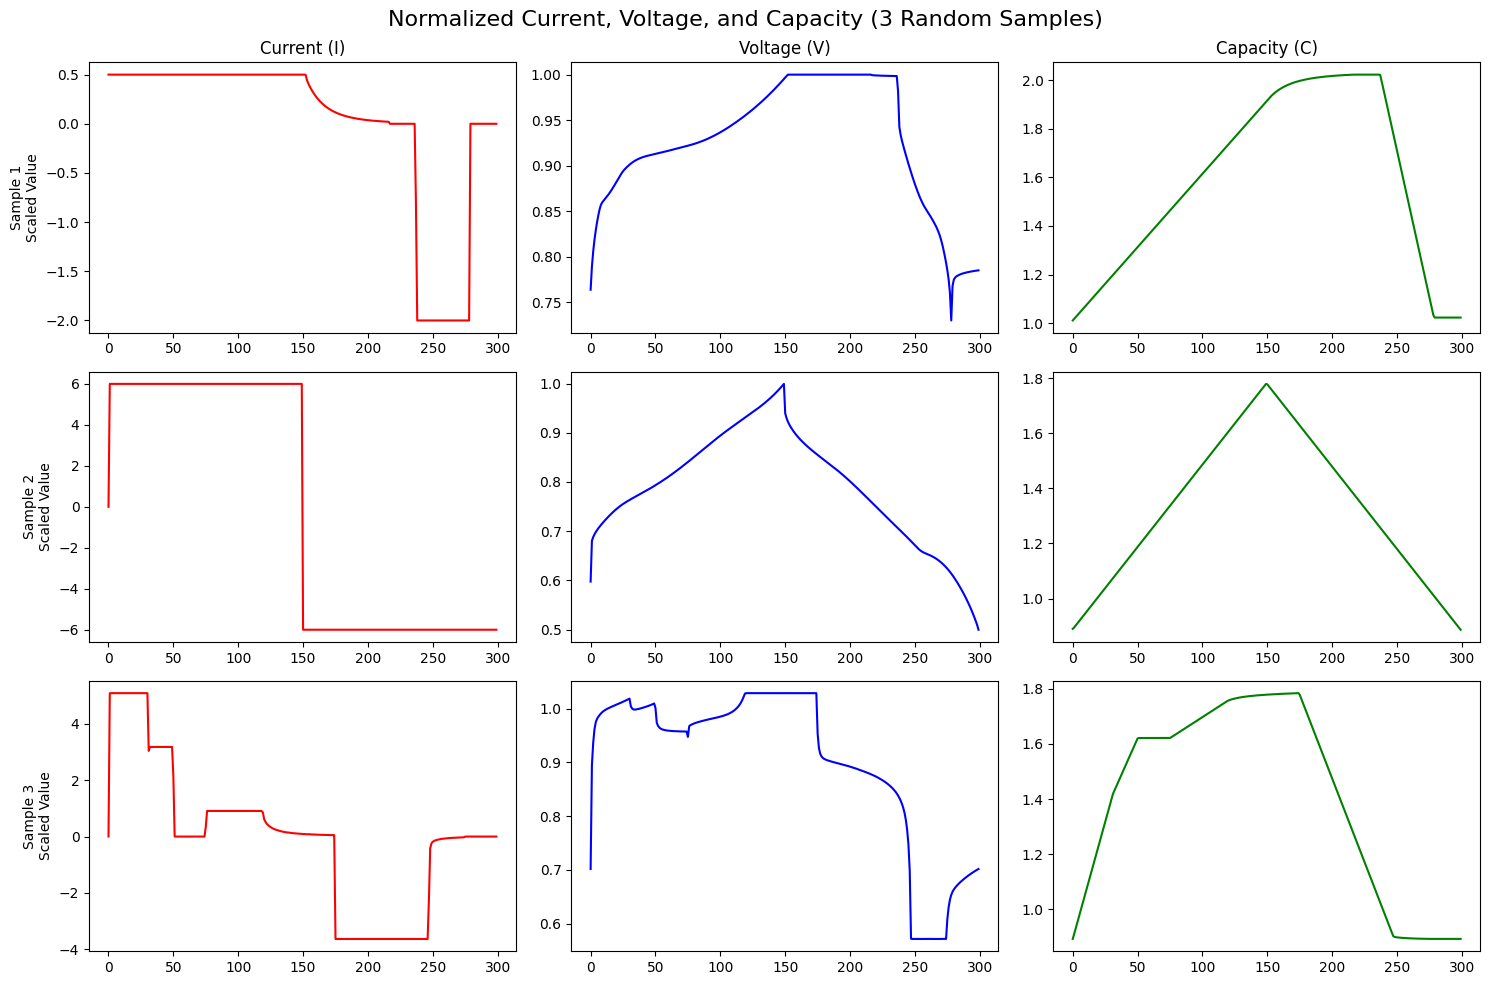

In [10]:
import matplotlib.pyplot as plt
import random

# Grab a single batch of data
train_features, train_labels = next(iter(train_loader))

# Set up the plot to show 3 random batteries to see if they are squashed
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Normalized Current, Voltage, and Capacity (3 Random Samples)", fontsize=16)

for i in range(3):
    # Pick a random battery from this batch
    idx = random.randint(0, train_features.size(0) - 1)
    
    # Squeeze out the channel dim -> Shape: [3, 300]
    sample = train_features[idx].squeeze(0).numpy() 
    
    current = sample[0]
    voltage = sample[1]
    capacity = sample[2]
    
    time_steps = range(300)
    
    # Plot Current
    axes[i, 0].plot(time_steps, current, color='red')
    axes[i, 0].set_ylabel(f"Sample {i+1}\nScaled Value")
    if i == 0: axes[i, 0].set_title("Current (I)")
    
    # Plot Voltage
    axes[i, 1].plot(time_steps, voltage, color='blue')
    if i == 0: axes[i, 1].set_title("Voltage (V)")
    
    # Plot Capacity
    axes[i, 2].plot(time_steps, capacity, color='green')
    if i == 0: axes[i, 2].set_title("Capacity (C)")

plt.tight_layout()
plt.show()

In [34]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels}")
print(f"Squeezed shape: {train_features.squeeze(1).shape}")

Feature batch shape: torch.Size([64, 1, 4, 300])
Labels batch shape: tensor([0.1596, 0.0744, 0.0480, 0.0928, 0.1582, 0.1218, 0.0944, 0.1634, 0.1704,
        0.0286, 0.1622, 0.4409, 0.1364, 0.1298, 0.0214, 0.1196, 0.1194, 0.0662,
        0.1818, 0.4677, 0.0856, 0.0284, 0.0204, 0.4123, 0.1020, 0.2106, 0.0818,
        0.0814, 0.0370, 0.1742, 0.0916, 0.1028, 0.0230, 0.2034, 0.1330, 0.0534,
        0.1998, 0.0054, 0.1504, 0.0296, 0.0856, 0.2284, 0.1118, 0.1458, 0.3821,
        0.1242, 0.1542, 0.0846, 0.0828, 0.0980, 0.1328, 0.1696, 0.1066, 0.1050,
        0.3063, 0.1114, 0.0926, 0.0588, 0.2338, 0.1718, 0.1588, 0.0452, 0.5529,
        0.1710])
Squeezed shape: torch.Size([64, 4, 300])


Using cuda, gpu -> NVIDIA GeForce RTX 5080
Epoch 0000 | Train Error: 518.2 cycles | Val Error: 527.6 cycles
Epoch 0010 | Train Error: 345.6 cycles | Val Error: 388.8 cycles
Epoch 0020 | Train Error: 360.1 cycles | Val Error: 405.4 cycles
Epoch 0030 | Train Error: 336.4 cycles | Val Error: 388.3 cycles
Epoch 0040 | Train Error: 302.1 cycles | Val Error: 327.6 cycles
Epoch 0050 | Train Error: 270.3 cycles | Val Error: 273.7 cycles
Epoch 0060 | Train Error: 293.9 cycles | Val Error: 357.3 cycles
Epoch 0070 | Train Error: 266.1 cycles | Val Error: 249.6 cycles
Epoch 0080 | Train Error: 240.5 cycles | Val Error: 243.2 cycles
Epoch 0090 | Train Error: 270.4 cycles | Val Error: 256.1 cycles
Epoch 0100 | Train Error: 246.5 cycles | Val Error: 237.3 cycles
Epoch 0110 | Train Error: 224.2 cycles | Val Error: 221.2 cycles
Epoch 0120 | Train Error: 219.0 cycles | Val Error: 218.2 cycles
Epoch 0130 | Train Error: 241.5 cycles | Val Error: 243.5 cycles
Epoch 0140 | Train Error: 235.3 cycles | Val Er

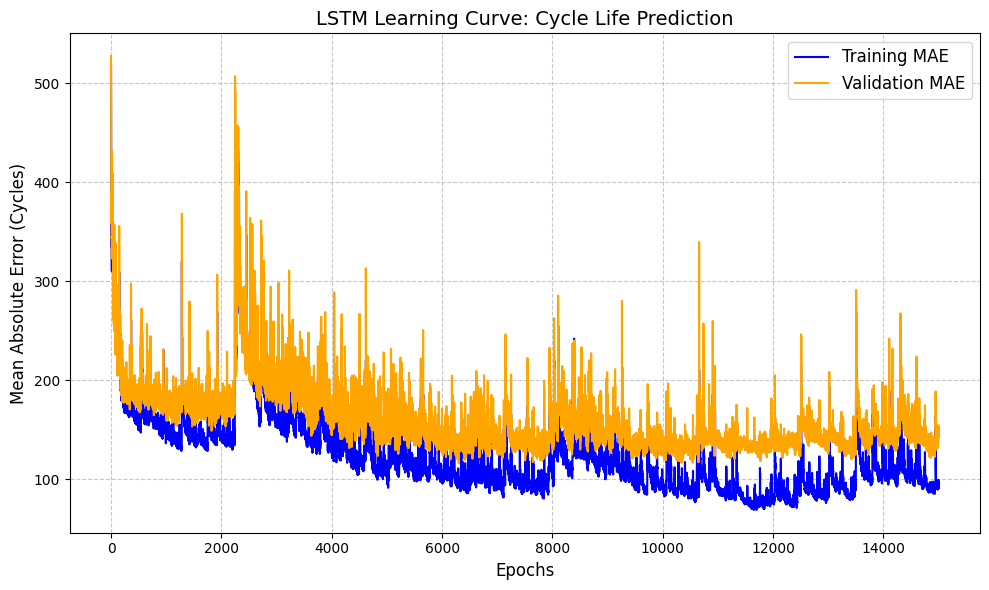

: 

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt # <--- Added for plotting

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}, gpu -> {torch.cuda.get_device_name(0) if torch.cuda.is_available() is True else 'N/A'}")

y_max = y_max.to(device)

class LSTMnetwork(nn.Module):
    def __init__(self, hidden_size=75, num_layers=3):
        super(LSTMnetwork, self).__init__()

        self.lstm = nn.LSTM(
            input_size=4,  # <--- Set to 4 to accept the Scale channel
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.3
        )
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1) 
        _, (hidden_layers, _) = self.lstm(x)
        cycle_to_80_pred = self.out(hidden_layers[-1]) 

        return cycle_to_80_pred.flatten()

model = LSTMnetwork(hidden_size=100, num_layers=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()

# ==========================
# 4. TRAINING & VALIDATION LOOP
# ==========================
epochs = 15000

# Lists to keep track of our errors so we can plot them later
train_mae_history = []
val_mae_history = []

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() # Set the model to training mode (enables gradients and dropout)
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        # Move data to the Mac/PC GPU
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        preds = model(batch_x)   
        
        # Calculate MSE loss on normalized data for the optimizer
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()

        # Calculate MAE in real cycle numbers for human readability
        with torch.no_grad():
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (turns off dropout, locks weights)
    val_loss = 0
    val_mae = 0

    # torch.no_grad() tells PyTorch not to calculate gradients (saves memory/time)
    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            # Move data to the GPU
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            
            # Calculate validation loss
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            # Calculate validation MAE in real cycle numbers
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    # --- PRINT RESULTS ---
    # Print every 10 epochs to keep the console clean
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:04d} | "
              f"Train Error: {avg_train_mae:.1f} cycles | "
              f"Val Error: {avg_val_mae:.1f} cycles")

# ==========================
# 5. PLOT RESULTS
# ==========================
plt.figure(figsize=(10, 6))
plt.plot(train_mae_history, label='Training MAE', color='blue', linewidth=1.5)
plt.plot(val_mae_history, label='Validation MAE', color='orange', linewidth=1.5)

plt.title('LSTM Learning Curve: Cycle Life Prediction', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Using cuda
Epoch 0000 | Train Error: 704.8 cycles | Val Error: 600.0 cycles
Epoch 0010 | Train Error: 354.9 cycles | Val Error: 443.9 cycles
Epoch 0020 | Train Error: 338.9 cycles | Val Error: 300.9 cycles
Epoch 0030 | Train Error: 304.1 cycles | Val Error: 350.2 cycles
Epoch 0040 | Train Error: 294.0 cycles | Val Error: 328.1 cycles
Epoch 0050 | Train Error: 268.9 cycles | Val Error: 227.2 cycles
Epoch 0060 | Train Error: 271.6 cycles | Val Error: 256.4 cycles
Epoch 0070 | Train Error: 267.0 cycles | Val Error: 284.9 cycles
Epoch 0080 | Train Error: 274.0 cycles | Val Error: 313.2 cycles
Epoch 0090 | Train Error: 281.7 cycles | Val Error: 287.0 cycles
Epoch 0100 | Train Error: 253.5 cycles | Val Error: 256.4 cycles
Epoch 0110 | Train Error: 257.4 cycles | Val Error: 276.8 cycles
Epoch 0120 | Train Error: 259.6 cycles | Val Error: 243.9 cycles
Epoch 0130 | Train Error: 260.1 cycles | Val Error: 215.6 cycles
Epoch 0140 | Train Error: 241.7 cycles | Val Error: 237.6 cycles
Epoch 0150 | T

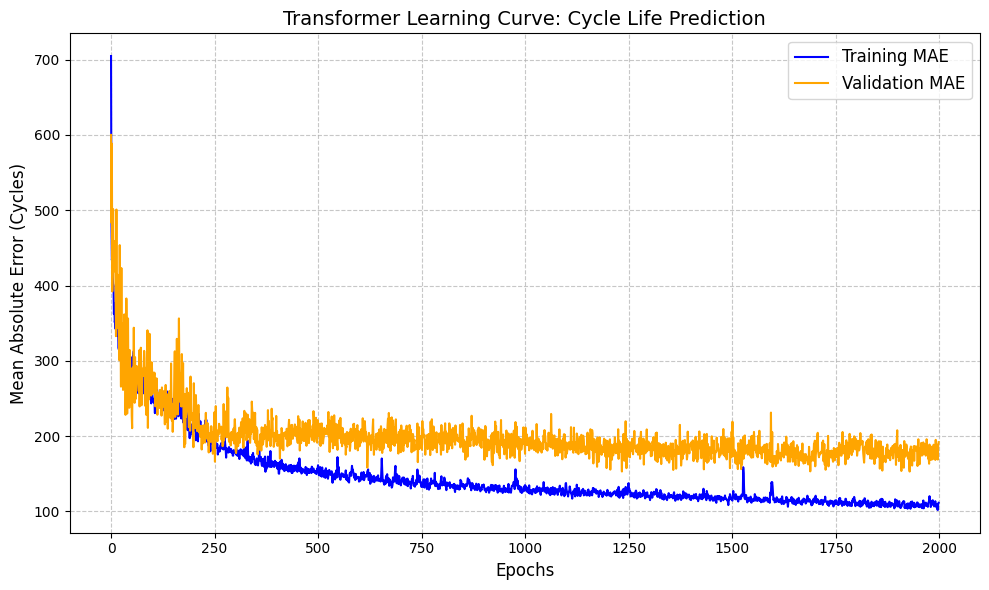

In [43]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

# Device configuration
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}")

# ==========================
# 1. POSITIONAL ENCODING
# ==========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create constant 'pe' matrix with values dependent on pos and i
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ==========================
# 2. TRANSFORMER NETWORK
# ==========================
class TransformerNetwork(nn.Module):
    def __init__(self, input_size=4, d_model=96, nhead=4, num_layers=4, dropout=0.2):
        super(TransformerNetwork, self).__init__()
        
        # 1. Convolutional Stem: Captures local slopes/trends
        self.conv_embedding = nn.Conv1d(in_channels=input_size, 
                                        out_channels=d_model, 
                                        kernel_size=5, 
                                        padding=2) 
        
        # 2. Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True,
            activation="gelu" 
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Output Head
        self.out = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        x = x.squeeze(1) 
        x = self.conv_embedding(x) 
        x = x.permute(0, 2, 1)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x) 
        
        # Global Average Pooling
        x = torch.mean(x, dim=1) 
        pred = self.out(x)
        
        return pred.flatten()

# ==========================
# 3. SETUP 
# ==========================
model = TransformerNetwork(
    input_size=4,    # IMPORTANT: Updated to 4 to accept our new Scale channel
    d_model=152,      
    nhead=4,         
    num_layers=4,    
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 
criterion = nn.MSELoss()

# ==========================
# 4. TRAINING & VALIDATION LOOP
# ==========================
epochs = 2000

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        preds = model(batch_x)   
        
        loss = criterion(preds, batch_y)
        loss.backward()
        
        # CRUCIAL FIX FOR TRANSFORMERS: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)

    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    # Print every 10 epochs to keep the console clean
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:04d} | Train Error: {avg_train_mae:.1f} cycles | Val Error: {avg_val_mae:.1f} cycles")

# ==========================
# 5. PLOT RESULTS
# ==========================
plt.figure(figsize=(10, 6))
plt.plot(train_mae_history, label='Training MAE', color='blue', linewidth=1.5)
plt.plot(val_mae_history, label='Validation MAE', color='orange', linewidth=1.5)

plt.title('Transformer Learning Curve: Cycle Life Prediction', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()